# Infinite Cylinder TMatrixC

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
import treams

In [3]:
k0s = 2 * np.pi * np.linspace(1 / 6000, 1 / 300, 200)
materials = [treams.Material(16 + 0.5j), treams.Material()]
mmax = 4
radius = 75
kzs = [0]
cylinders = [treams.TMatrixC.cylinder(kzs, mmax, k0, radius, materials) for k0 in k0s]

In [4]:
xw_sca = np.array([tm.xw_sca_avg for tm in cylinders]) / (2 * radius)
xw_ext = np.array([tm.xw_ext_avg for tm in cylinders]) / (2 * radius)

In [5]:
cwb_mmax0 = treams.CylindricalWaveBasis.default(kzs, 0)
cylinders_mmax0 = [tm[cwb_mmax0] for tm in cylinders]
xw_sca_mmax0 = np.array([tm.xw_sca_avg for tm in cylinders_mmax0]) / (2 * radius)
xw_ext_mmax0 = np.array([tm.xw_ext_avg for tm in cylinders_mmax0]) / (2 * radius)

In [6]:
tm = cylinders[-1]
inc = treams.plane_wave([tm.k0, 0, 0], 1, k0=tm.k0, material=tm.material)
sca = tm @ inc.expand(tm.basis)

/home/runner/work/treams/treams/src/treams/_operators.py:607: UserWarning: 'where' used without 'out', expect unitialized memory in output. If this is intentional, use out=None.
  res = pw.to_cw(


In [7]:
x = np.linspace(-100, 100, 101)
y = np.linspace(-100, 100, 101)
z = 0
xx, yy = np.meshgrid(x, y, indexing="ij")
zz = np.full_like(xx, z)
grid = np.stack((xx, yy, zz), axis=-1)

In [8]:
intensity = np.zeros_like(xx)
valid = tm.valid_points(grid, [radius])
intensity[~valid] = np.nan
intensity[valid] = 0.5 * np.sum(
    np.abs(inc.efield(grid[valid]) + sca.efield(grid[valid])) ** 2, -1
)

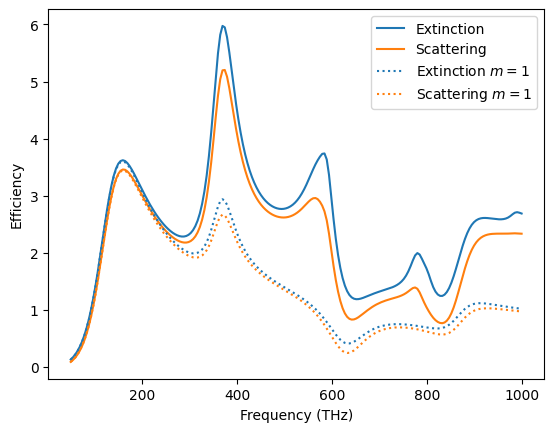

In [9]:
fig, ax = plt.subplots()
ax.plot(k0s * 299792.458 / (2 * np.pi), xw_ext)
ax.plot(k0s * 299792.458 / (2 * np.pi), xw_sca)
ax.plot(k0s * 299792.458 / (2 * np.pi), xw_ext_mmax0, color="C0", linestyle=":")
ax.plot(k0s * 299792.458 / (2 * np.pi), xw_sca_mmax0, color="C1", linestyle=":")
ax.set_xlabel("Frequency (THz)")
ax.set_ylabel("Efficiency")
ax.legend(["Extinction", "Scattering", "Extinction $m=1$", "Scattering $m=1$"])
fig.show()

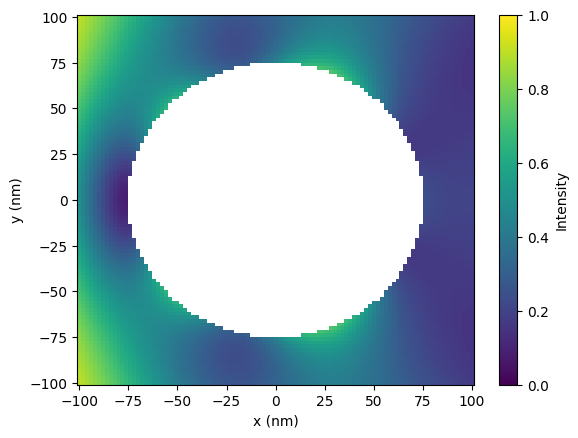

In [10]:
fig, ax = plt.subplots()
pcm = ax.pcolormesh(
    xx, yy, intensity, shading="nearest", vmin=0, vmax=1,
)
cb = plt.colorbar(pcm)
cb.set_label("Intensity")
ax.set_xlabel("x (nm)")
ax.set_ylabel("y (nm)")
fig.show()